# Exercise 2: Tactical reconnaissance UAV mission planning (Defense)

Scenario consistent with the chapter: 3D grid 30×30×10 (3 km × 3 km × 500 m), two radars and comparison:

- Approach A: classical 3D A* (priority: short route),
- Approach B: hybrid with `simulate_llm_tactics(...)` (priority: safety).

In [1]:
import heapq
import math
import time
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 3D Grid: 30x30x10 => 100m x 100m x 50m per cell
NX, NY, NZ = 30, 30, 10
CELL_XY_M = 100
CELL_Z_M = 50

START = (0, 0, 5)
GOAL = (25, 25, 5)
SAFE_POINT = (29, 29, 5)  # evacuation point after radar B activation

radars = {
    'A': {'xy': (10, 10), 'range_cells': 10, 'active': True},   # 1.0 km
    'B': {'xy': (20, 5),  'range_cells': 15, 'active': False},  # 1.5 km
}

print('Start:', START, 'Goal:', GOAL, 'Safe:', SAFE_POINT)
print('Radars:', radars)

Start: (0, 0, 5) Goal: (25, 25, 5) Safe: (29, 29, 5)
Radary: {'A': {'xy': (10, 10), 'range_cells': 10, 'active': True}, 'B': {'xy': (20, 5), 'range_cells': 15, 'active': False}}


In [2]:
def in_bounds(p):
    x, y, z = p
    return 0 <= x < NX and 0 <= y < NY and 0 <= z < NZ

def neighbors6(p):
    x, y, z = p
    # Order of neighbors affects tie-break in A* (we prefer movement +X, then +Y)
    cand = [(x+1,y,z),(x,y+1,z),(x-1,y,z),(x,y-1,z),(x,y,z+1),(x,y,z-1)]
    return [q for q in cand if in_bounds(q)]

def dist_xy(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def effective_range(radar, z):
    """Simplified radar horizon model: a low-flying target is masked
    by terrain and Earth curvature, so effective detection range increases with flight altitude
    (z in cells, 1 cell = 50 m). Thus, 'low altitude' tactic
    realistically reduces detectability, not just changes the route horizontally."""
    factor = min(1.0, 0.4 + 0.12 * z)
    return radar['range_cells'] * factor

def in_radar_zone(p, radar):
    x, y, z = p
    cx, cy = radar['xy']
    return dist_xy((x, y), (cx, cy)) <= effective_range(radar, z)

def detection_events(path, radars_cfg):
    events = 0
    for p in path:
        for r in radars_cfg.values():
            if r['active'] and in_radar_zone(p, r):
                events += 1
                break
    return events

def astar3d(start, goal, radars_cfg, radar_penalty=0.0, z_max=None):
    """A* 3D: base step cost = 1, optional penalty for radar zone and altitude."""
    def h(a, b):
        return abs(a[0]-b[0]) + abs(a[1]-b[1]) + abs(a[2]-b[2])

    t0 = time.perf_counter()
    tie = 0
    open_heap = [(h(start, goal), 0.0, tie, start)]
    g = {start: 0.0}
    parent = {start: None}
    closed = set()

    while open_heap:
        _, gc, _, node = heapq.heappop(open_heap)
        if node in closed:
            continue
        closed.add(node)

        if node == goal:
            break

        for nb in neighbors6(node):
            if z_max is not None and nb[2] > z_max:
                continue

            step_cost = 1.0
            for r in radars_cfg.values():
                if r['active'] and in_radar_zone(nb, r):
                    step_cost += radar_penalty

            ng = gc + step_cost
            if ng < g.get(nb, np.inf):
                g[nb] = ng
                parent[nb] = node
                tie += 1
                heapq.heappush(open_heap, (ng + h(nb, goal), ng, tie, nb))

    ms = (time.perf_counter() - t0) * 1000
    if goal not in parent:
        return None, np.inf, len(closed), ms

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, g[goal], len(closed), ms

In [3]:
# Approach A: classical (no radar penalties)
path_A, cost_A, exp_A, ms_A = astar3d(START, GOAL, radars, radar_penalty=0.0, z_max=None)
det_A = detection_events(path_A, radars)
print(f'Classical A*: steps={len(path_A)}, cost={cost_A:.1f}, detections={det_A}, time={ms_A:.2f} ms')

Classical A*: steps=51, cost=50.0, detections=1, time=5.80 ms


In [4]:
def simulate_llm_tactics(uav_pos, radars_cfg, status):
    """Rules consistent with chapter: niski_pulap (low altitude) / ewakuacja (evacuation) / kontynuuj (continue)."""
    if status.get('radar_B_active', False):
        return {'strategia': 'ewakuacja', 'z_max': None, 'radar_penalty': 200.0, 'target': SAFE_POINT}

    for r in radars_cfg.values():
        d = dist_xy((uav_pos[0], uav_pos[1]), r['xy'])
        if d < 1.2 * r['range_cells']:
            return {'strategia': 'niski_pulap', 'z_max': 2, 'radar_penalty': 8.0, 'target': GOAL}

    return {'strategia': 'kontynuuj', 'z_max': None, 'radar_penalty': 2.0, 'target': GOAL}

status = {'radar_B_active': False}
decision0 = simulate_llm_tactics(START, radars, status)
path_B0, cost_B0, exp_B0, ms_B0 = astar3d(START, decision0['target'], radars,
                                       radar_penalty=decision0['radar_penalty'],
                                       z_max=decision0['z_max'])
det_B0 = detection_events(path_B0, radars)
print('Initial strategy:', decision0)
print(f'LLM-hybrid (before B activation): steps={len(path_B0)}, cost={cost_B0:.1f}, detections={det_B0}, time={ms_B0:.2f} ms')

Initial strategy: {'strategia': 'kontynuuj', 'z_max': None, 'radar_penalty': 2.0, 'target': (25, 25, 5)}
LLM-hybrid (before B activation): steps=51, cost=52.0, detections=1, time=7.24 ms


In [5]:
# Test consistent with the chapter: radar B activates randomly at step t=15
t = 15
uav_t = path_A[min(t, len(path_A)-1)]
activate_B = np.random.rand() < 0.9  # randomly, but usually activates for demonstration
radars_t = {k: dict(v) for k, v in radars.items()}
radars_t['B']['active'] = bool(activate_B)
print('UAV position at t=15:', uav_t)
print('Radar B randomly activated?:', activate_B)

# Classical replanning: continue to goal, no safety penalties
path_A_re, cost_A_re, exp_A_re, ms_A_re = astar3d(uav_t, GOAL, radars_t, radar_penalty=0.0, z_max=None)
path_A_full = path_A[:t] + path_A_re

# Hybrid: tactical LLM decision after activation
status_t = {'radar_B_active': bool(activate_B)}
decision_t = simulate_llm_tactics(uav_t, radars_t, status_t)
print('LLM decision after activation:', decision_t)
path_B_re, cost_B_re, exp_B_re, ms_B_re = astar3d(uav_t, decision_t['target'], radars_t,
                                       radar_penalty=decision_t['radar_penalty'],
                                       z_max=decision_t['z_max'])
path_B_full = path_A[:t] + path_B_re

# Detections are counted after activation (from step t), as this is a strategy response comparison.
det_A_full = detection_events(path_A_re, radars_t)
det_B_full = detection_events(path_B_re, radars_t)

# Success: classical = reaching goal, hybrid = reaching goal or safe zone
success_A = int(path_A_full[-1] == GOAL)
success_B = int(path_B_full[-1] in [GOAL, START, SAFE_POINT])

print('LLM decision after activation:', decision_t)
print(f'A* after t=15: steps={len(path_A_full)}, detections_after_t={det_A_full}, success={success_A}')
print(f'LLM after t=15: steps={len(path_B_full)}, detections_after_t={det_B_full}, success={success_B}')

UAV position at t=15: (15, 0, 5)
Radar B randomly activated?: True
LLM decision after activation: {'strategia': 'ewakuacja', 'z_max': None, 'radar_penalty': 200.0, 'target': (29, 29, 5)}
A* after t=15: steps=51, detections_after_t=30, success=1
LLM after t=15: steps=73, detections_after_t=5, success=1


In [6]:
print('=' * 64)
print('METRICS COMPARISON (after radar B activation at t=15)')
print('=' * 64)
print('Metric'.ljust(30) + 'Classical A*'.rjust(14) + 'LLM-hybrid'.rjust(14))
print('-' * 64)
print('Path length [cells]'.ljust(30) + str(len(path_A_full)).rjust(14) + str(len(path_B_full)).rjust(14))
print('Detections after t=15'.ljust(30) + str(det_A_full).rjust(14) + str(det_B_full).rjust(14))
print('Mission success [0/1]'.ljust(30) + str(success_A).rjust(14) + str(success_B).rjust(14))
print('Replanning time [ms]'.ljust(30) + f'{ms_A_re:.2f}'.rjust(14) + f'{ms_B_re:.2f}'.rjust(14))
print('=' * 64)

METRICS COMPARISON (after radar B activation at t=15)
Metryka                         A* klasyczne   LLM-hybryda
----------------------------------------------------------------
Path length [cells]                 51            73
Detekcje po t=15                          30             5
Sukces misji [0/1]                         1             1
Czas replanningu [ms]                   2.61         12.34


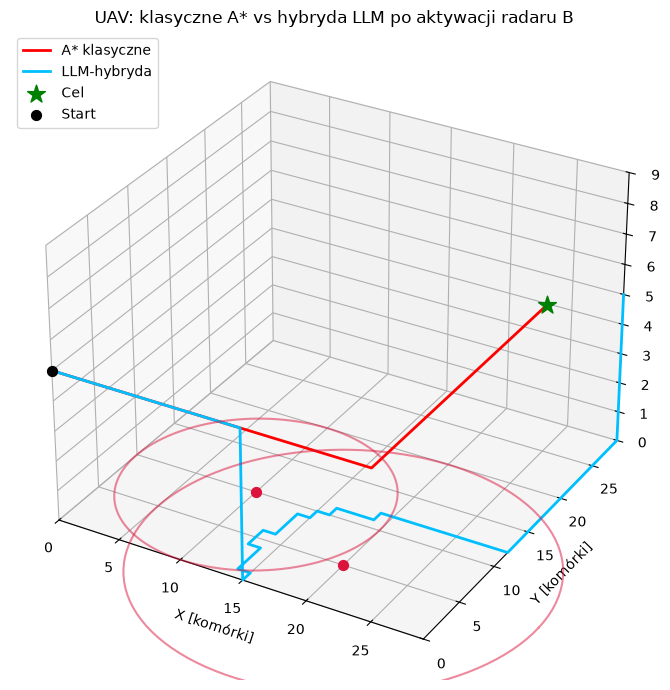

In [7]:
# Wizualizacja 3D (trajektorie + radary)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

def plot_path(path, color, label):
    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    zs = [p[2] for p in path]
    ax.plot(xs, ys, zs, color=color, linewidth=2.0, label=label)

plot_path(path_A_full, 'red', 'A* klasyczne')
plot_path(path_B_full, 'deepskyblue', 'LLM-hybryda')

# Radars: point + range circle on XY plane
theta = np.linspace(0, 2*np.pi, 120)
for name, r in radars_t.items():
    cx, cy = r['xy']
    rr = r['range_cells']
    x_ring = cx + rr * np.cos(theta)
    y_ring = cy + rr * np.sin(theta)
    z_ring = np.zeros_like(theta)
    color = 'crimson' if r['active'] else 'gray'
    ax.plot(x_ring, y_ring, z_ring, color=color, alpha=0.5)
    ax.scatter([cx], [cy], [0], color=color, s=50)

ax.scatter([GOAL[0]], [GOAL[1]], [GOAL[2]], color='green', marker='*', s=180, label='Cel')
ax.scatter([START[0]], [START[1]], [START[2]], color='black', marker='o', s=50, label='Start')

ax.set_title('UAV: klasyczne A* vs hybryda LLM po aktywacji radaru B')
ax.set_xlabel('X [cells]')
ax.set_ylabel('Y [cells]')
ax.set_zlabel('Z [cells]')
ax.set_xlim(0, NX-1); ax.set_ylim(0, NY-1); ax.set_zlim(0, NZ-1)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()